<a href="https://colab.research.google.com/github/Ma7R7/Algoritmos-Optimizaci-n-Marina-/blob/main/Algoritmos_AG2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG2 - Actividad Guiada 2
Nombre: Marina Riquelme Morell<br>
Link:   https://colab.research.google.com/drive/1ca2SxHyZxpTc4aAOgkH2YESqauTyvhYl?usp=sharing <br>
Github:https://github.com/Ma7R7/Algoritmos-Optimizaci-n-Marina-/blob/main/Algoritmos_AG2.ipynb
<br>




In [14]:
import math

##Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

###Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

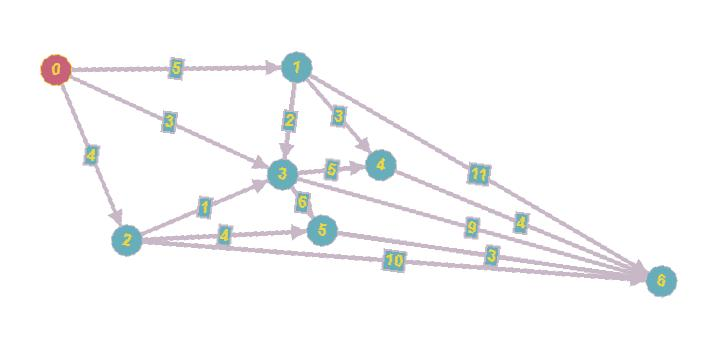

*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [15]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [16]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [17]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [18]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)


La ruta es:


'0,2,5'

##Problema de Asignacion de tarea

In [19]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [20]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
  return VALOR



valor((3,2,  ),COSTES)

34

In [21]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((0,1),COSTES)

68

In [22]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [23]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [24]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4


## Ramificación y poda. Práctica.
Análisis para mejorar nota:

- ¿Que complejidad tiene el algoritmo por fuerza bruta?
- ¿A partir de que dimensión el algoritmo por fuerza bruta deja de
ser una opción?
- ¿Hay algún valor de la dimensión a partir de la cual el algoritmo de
ramificación y poda deja de ser una opción válida?
- Generar matrices con valores aleatorios de mayores dimensiones
(5,6,7,…) y ejecutar ambos algoritmos.

El enfoque de fuerza bruta explora todas las permutaciones posibles, mientras que la técnica de ramificación y poda utiliza cotas para descartar soluciones parciales que no superarán a la mejor solución hallada hasta el momento, optimizando así la búsqueda en el espacio de estados.

In [4]:
import random
import time
from itertools import permutations

# Función de fuerza bruta.
def fuerza_bruta(costes):
    """
    Evalúa todas las combinaciones posibles de asignación para hallar el coste mínimo.
    """
    n = len(costes)
    mejor_valor = float('inf')
    # Generación de todas las permutaciones de las tareas.
    for p in permutations(range(n)):
        valor_actual = sum(costes[i][p[i]] for i in range(n))
        if valor_actual < mejor_valor:
            mejor_valor = valor_actual
    return mejor_valor

# Generación de matrices aleatorias y ejecución.
dimensiones = [5, 6, 7, 8, 9, 10]

for d in dimensiones:
    # Se genera una matriz cuadrada de dimensión d con costes aleatorios.
    matriz_aleatoria = [[random.randint(10, 50) for _ in range(d)] for _ in range(d)]

    print(f"--- Dimensión {d} ---")

    # Ejecución y tiempos de la fuerza bruta.
    inicio_fb = time.time()
    resultado_fb = fuerza_bruta(matriz_aleatoria)
    tiempo_fb = time.time() - inicio_fb
    print(f"Fuerza bruta: Valor {resultado_fb} en {tiempo_fb:.6f} segundos.")

    # Ejecución y tiempos de ramificación y poda.
    inicio_rp = time.time()
    ramificacion_y_poda(matriz_aleatoria)
    tiempo_rp = time.time() - inicio_rp
    print(f"Ramificación y poda: Ejecutada en {tiempo_rp:.6f} segundos.")
    print("-" * 30)

--- Dimensión 5 ---
Fuerza bruta: Valor 94 en 0.000154 segundos.
Ramificación y poda: Ejecutada en 0.000697 segundos.
------------------------------
--- Dimensión 6 ---
Fuerza bruta: Valor 91 en 0.001420 segundos.
Ramificación y poda: Ejecutada en 0.000462 segundos.
------------------------------
--- Dimensión 7 ---
Fuerza bruta: Valor 116 en 0.004499 segundos.
Ramificación y poda: Ejecutada en 0.011951 segundos.
------------------------------
--- Dimensión 8 ---
Fuerza bruta: Valor 111 en 0.039684 segundos.
Ramificación y poda: Ejecutada en 0.006688 segundos.
------------------------------
--- Dimensión 9 ---
Fuerza bruta: Valor 152 en 0.546014 segundos.
Ramificación y poda: Ejecutada en 0.142869 segundos.
------------------------------
--- Dimensión 10 ---
Fuerza bruta: Valor 149 en 3.948509 segundos.
Ramificación y poda: Ejecutada en 0.030105 segundos.
------------------------------


El algoritmo de fuerza bruta presenta un crecimiento factorial ($O(n!)$).

El salto de $n=9$ (0,54 s) a $n=10$ (3,94 s) supone un incremento de aproximadamente 7,2 veces el tiempo de ejecución, confirmando su inviabilidad para dimensiones mayores.

El algoritmo de ramificación y poda exhibe una escalabilidad superior. Aunque en dimensiones bajas ($n=7$) puede sufrir por el coste computacional del cálculo de cotas frente a la simplicidad de la fuerza bruta, su rendimiento en $n=10$ es 131 veces más rápido que la búsqueda exhaustiva.

Los resultados en $n=10$ (0,03 s) indican que el algoritmo de ramificación y poda logró descartar gran parte del árbol de soluciones de forma temprana, manteniendo el tiempo de respuesta en valores despreciables.

##Descenso del gradiente

In [25]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [26]:
#Definimos la funcion
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

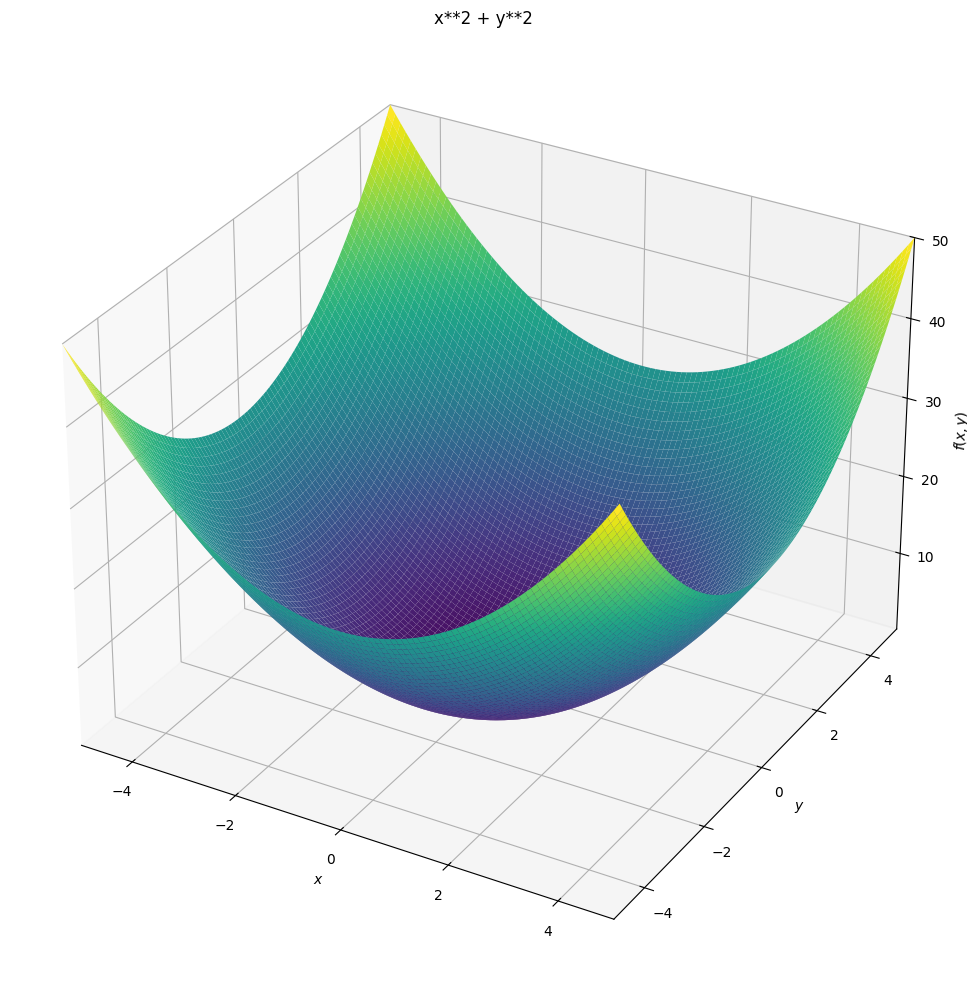

In [27]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

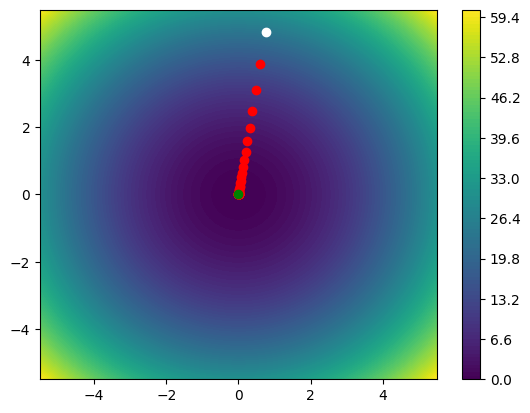

Solucion: [1.0816182284146835e-05, 6.906205212243285e-05] 4.886556842565523e-09


In [28]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=5.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-5,5  ),random.uniform(-5,5 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:50
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
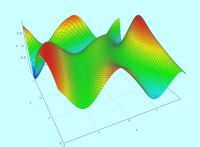


Optimizamos la función propuesta incluyendo en el código las modificaciones requeridas para su ejecución satisfactoria.

In [3]:
#Definimos la funcion
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )


In [5]:
import math

# Definimos la funcion.
f = lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) * math.cos(2*X[0] + 1 - math.exp(X[1]))

# Definimos el gradiente.
df = lambda X: [
    (X[0] * math.cos(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) * math.cos(2*X[0] + 1 - math.exp(X[1]))) -
    (2 * math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) * math.sin(2*X[0] + 1 - math.exp(X[1]))),

    (-1/2 * X[1] * math.cos(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) * math.cos(2*X[0] + 1 - math.exp(X[1]))) +
    (math.exp(X[1]) * math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) * math.sin(2*X[0] + 1 - math.exp(X[1])))
]

# Prueba de evaluación del gradiente en el punto [1, 2].
print(df([1, 2]))

[-0.8803745550791662, 3.9384502467765357]


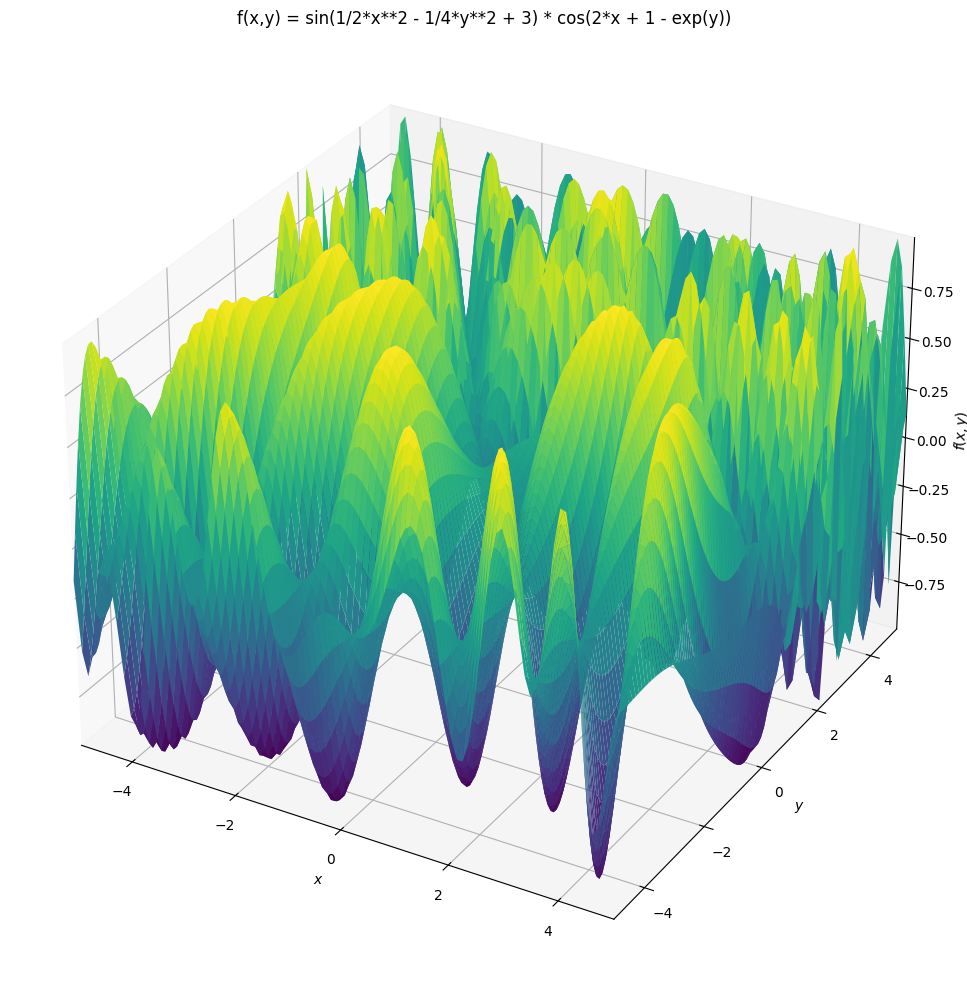

In [6]:
from sympy import symbols, sin, cos, exp
from sympy.plotting import plot3d

x, y = symbols('x y')

# Definición de la función en formato simbólico para SymPy.
f_simbolica = sin(1/2 * x**2 - 1/4 * y**2 + 3) * cos(2*x + 1 - exp(y))

# Representación gráfica en 3D.
plot3d(f_simbolica,
       (x, -5, 5), (y, -5, 5),
       title='f(x,y) = sin(1/2*x**2 - 1/4*y**2 + 3) * cos(2*x + 1 - exp(y))',
       size=(10, 10))

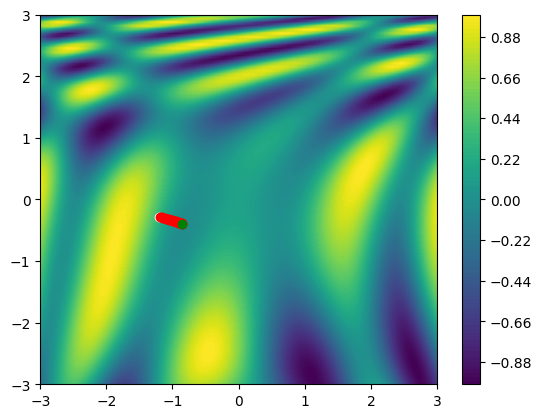

Solucion: [-0.8585448510132694, -0.3915098202517725] -0.03314193872236333


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# Prepara los datos para dibujar mapa de niveles.
resolucion = 100
# Reducimos el rango para mantener la estabilidad del término e^Y.
rango = 3.0

X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros((resolucion, resolucion))
for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[iy, ix] = f([x, y])

# Pinta el mapa de niveles.
plt.contourf(X, Y, Z, resolucion)
plt.colorbar()

# Generamos un punto aleatorio inicial dentro del nuevo rango y pintamos de blanco.
P = [random.uniform(-rango, rango), random.uniform(-rango, rango)]
plt.plot(P[0], P[1], "o", c="white")

# Tasa de aprendizaje reducida para asegurar pasos estables frente a gradientes altos.
TA = 0.01

# Iteraciones: 50.
for _ in range(50):
    grad = df(P)
    P[0], P[1] = P[0] - TA*grad[0], P[1] - TA*grad[1]
    plt.plot(P[0], P[1], "o", c="red")

# Dibujamos el punto final y pintamos de verde.
plt.plot(P[0], P[1], "o", c="green")
plt.show()

print("Solucion:", P, f(P))